In [1]:
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")

import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2")

import torch
from common.causal_gradient import (
    LatentNormalizer,
    RolloutRunner,
    FiniteDifferenceProbe,
    RandomDirectionSampler,
)

In [3]:
# Compute cosine similarity matrix between all gradient results
import torch.nn.functional as F


def compute_cosine_similarity_matrix(results):
    """Compute pairwise cosine similarity matrix for gradient results."""
    n = len(results)
    cosine_sim_matrix = torch.zeros(n, n)

    # Compute cosine similarity for each pair (only upper triangle since it's symmetric)
    for i in range(n):
        for j in range(i, n):
            grad_i = results[i].gradient
            grad_j = results[j].gradient

            # Compute cosine similarity
            cos_sim = F.cosine_similarity(grad_i.unsqueeze(0),
                                          grad_j.unsqueeze(0)).item()

            # Fill both (i,j) and (j,i) since matrix is symmetric
            cosine_sim_matrix[i, j] = cos_sim
            cosine_sim_matrix[j, i] = cos_sim

    return cosine_sim_matrix


In [4]:
def load_data(
    df_metadata,
    cart_position=None,
    pole_angle=None,
    normalization_method=None,
    seed=None,
):
    """
    Load intervention data from directories matching the specified criteria.
    
    Parameters can be single values or lists. If a parameter is None, it matches all values.
    
    Returns:
        pd.DataFrame: DataFrame with config info and episode data
    """

    # Convert single values to lists for uniform handling
    def to_list(val):
        if val is None:
            return None
        return val if isinstance(val, list) else [val]

    cart_position_list = to_list(cart_position)
    pole_angle_list = to_list(pole_angle)
    seed_list = to_list(seed)
    normalization_list = to_list(normalization_method)

    # Filter configs based on criteria
    filtered_configs = []
    for idx, config in df_metadata.iterrows():
        inital_state = config.get('initial_state')
        # Check each criterion
        if cart_position_list is not None and inital_state[
                0] not in cart_position_list:
            continue
        if pole_angle_list is not None and inital_state[
                1] not in pole_angle_list:
            continue
        if normalization_list is not None and config.get(
                'normalization_method') not in normalization_list:
            continue
        if seed_list is not None and config.get('config_seed') not in seed_list:
            continue

        filtered_configs.append(config)

    print(f"Found {len(filtered_configs)} configurations")
    # Load episode data for each matching config
    results = []
    for config in tqdm(filtered_configs):
        directory = Path(config['directory'])
        episode_path = directory / "activations" / "episode_0000.pkl"

        if episode_path.exists():
            # Load the pickled episode data
            with open(episode_path, 'rb') as f:
                episode_data = pickle.load(f)

            # Unflatten the data structure
            episode_data = episode_data['data']
            for key, value in episode_data.items():

                if key == 'latent_states':
                    config[key] = value.squeeze()
                else:
                    config[key] = value

            results.append(config)

    return pd.DataFrame(results)


def flatten_dict(d, parent_key='', sep='_'):
    """
    Flatten a nested dictionary.
    
    Args:
        d: Dictionary to flatten
        parent_key: String to prepend to keys
        sep: Separator between nested keys
    
    Returns:
        Flattened dictionary
    """
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


In [5]:
# Loop over all directories in the sweep logs
sweep_base_dir = Path("logs/021225-causal_gradient_sweep")

all_metadata = []
for sweep_dir in tqdm(sweep_base_dir.iterdir()):
    if sweep_dir.is_dir():
        metadata_path = sweep_dir / "config.json"
        if metadata_path.exists():
            with open(metadata_path, 'r') as f:
                try:
                    metadata = json.load(f)
                    # Flatten the nested metadata dictionary
                    flattened_metadata = flatten_dict(metadata)
                    # Add the directory path
                    flattened_metadata['directory'] = str(sweep_dir)

                except json.JSONDecodeError:
                    print(f"Error decoding JSON for {metadata_path}")
                    continue

        result_path = sweep_dir / "result.pkl"
        if result_path.exists():
            with open(result_path, 'rb') as f:
                results = pickle.load(f)
                gradient = results['gradient']
                flattened_metadata['gradient'] = gradient

        all_metadata.append(flattened_metadata)

print(f"Found {len(all_metadata)} configurations")
# Create DataFrame from flattened metadata

df_metadata = pd.DataFrame(all_metadata)


0it [00:00, ?it/s]

345it [01:18,  4.37it/s]

Found 344 configurations


In [6]:
df_metadata.head()

,perturbation_scale,horizon,num_directions,seed,starting_observation,initial_state_qpos_slider,initial_state_qpos_hinge_1,initial_state_qvel_slider,initial_state_qvel_hinge_1,directions,directory,gradient
0,0.010000,1,32,5,"[0.0, -1.0, 1.2246467991473532e-16, 0.0, 0.0]",0.0,3.141593,0.0,0.0,"[[0.008781041018664837, 0.09782098978757858, -...",logs/021225-causal_gradient_sweep/logs_2025120...,"[3.6315245e-07, -7.306524e-08, 1.892956e-07, -..."
1,0.000001,1,32,7,"[0.0, -1.0, 1.2246467991473532e-16, 0.0, 0.0]",0.0,3.141593,0.0,0.0,"[[0.008781041018664837, 0.09782098978757858, -...",logs/021225-causal_gradient_sweep/logs_2025120...,"[0.0016755105, 0.0016658826, 0.002133115, -0.0..."
2,1.000000,5,32,0,"[0.0, -1.0, 1.2246467991473532e-16, 0.0, 0.0]",0.0,3.141593,0.0,0.0,"[[0.008781041018664837, 0.09782098978757858, -...",logs/021225-causal_gradient_sweep/logs_2025120...,"[3.4210416e-07, -2.40664e-07, -1.4141162e-07, ..."
3,0.000001,1,128,4,"[0.0, -1.0, 1.2246467991473532e-16, 0.0, 0.0]",0.0,3.141593,0.0,0.0,"[[0.008781041018664837, 0.09782098978757858, -...",logs/021225-causal_gradient_sweep/logs_2025120...,"[0.0043010963, 0.015398585, 0.0068230536, -0.0..."
4,0.100000,5,64,2,"[0.0, -1.0, 1.2246467991473532e-16, 0.0, 0.0]",0.0,3.141593,0.0,0.0,"[[0.008781041018664837, 0.09782098978757858, -...",logs/021225-causal_gradient_sweep/logs_2025120...,"[-5.289828e-06, 4.636382e-06, -5.3165087e-07, ..."


## Conclusions

- ## eps = 1e-6 is too small, the gradient is too noisy.

## Are gradient norms similar?

/scratch/slurm_tmpdir/job_1589829/ipykernel_3834628/385773390.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


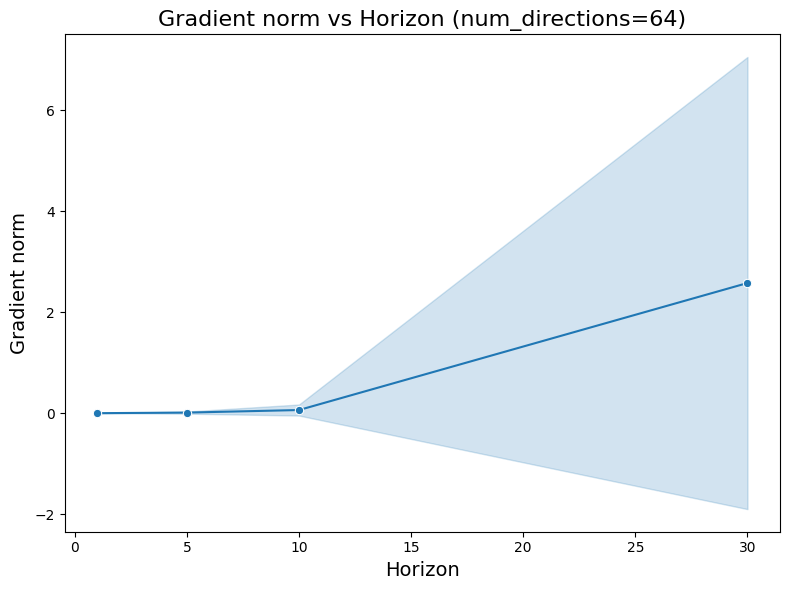

/scratch/slurm_tmpdir/job_1589829/ipykernel_3834628/385773390.py:29: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x="perturbation_scale",


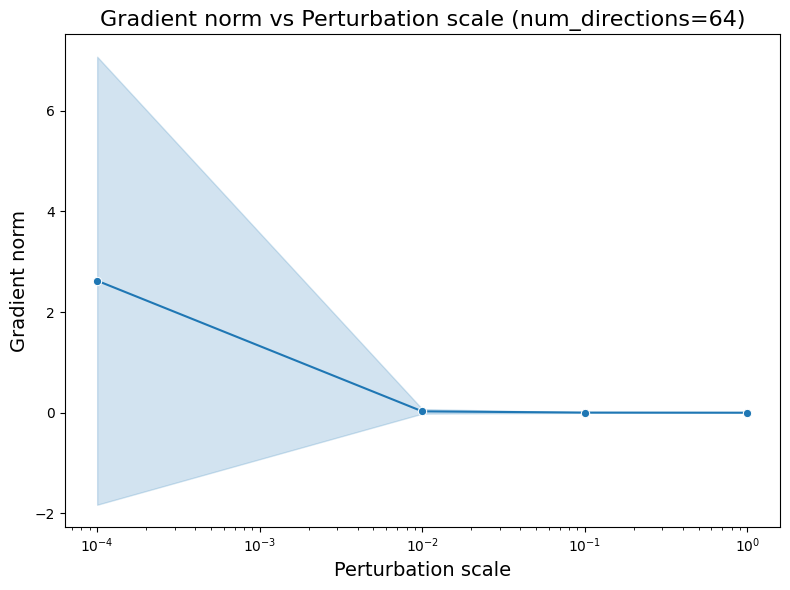

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Filter relevant rows: num_directions == 64
df_analysis = df_metadata[(df_metadata['num_directions'] == 64) & (
    df_metadata['perturbation_scale'].isin([1e-4, 1e-2, 1e-1, 1e-0]))].copy()
# Compute gradient norm for each row
df_analysis['grad_norm'] = df_analysis['gradient'].apply(
    lambda g: np.linalg.norm(g))

# --- Plot 1: Gradient norm vs Horizon (line plot with CI) ---
plt.figure(figsize=(8, 6))
sns.lineplot(
    x="horizon",
    y="grad_norm",
    data=df_analysis,
    ci='sd',  # (show sd, you can use 'sd' or 'se' or 95 for 95% CI)
    marker="o",
    err_style="band")
plt.xlabel("Horizon", fontsize=14)
plt.ylabel("Gradient norm", fontsize=14)
plt.title("Gradient norm vs Horizon (num_directions=64)", fontsize=16)
plt.tight_layout()
plt.show()

# --- Plot 2: Gradient norm vs Perturbation scale (line plot with CI) ---
plt.figure(figsize=(8, 6))
sns.lineplot(x="perturbation_scale",
             y="grad_norm",
             data=df_analysis,
             ci='sd',
             marker="o",
             err_style="band")
#plt.yscale("log")
plt.xlabel("Perturbation scale", fontsize=14)
plt.ylabel("Gradient norm", fontsize=14)
plt.title("Gradient norm vs Perturbation scale (num_directions=64)",
          fontsize=16)
plt.xscale("log")  # Usually helpful for scale
plt.tight_layout()
plt.show()


## Are gradients pointing to the same direction?

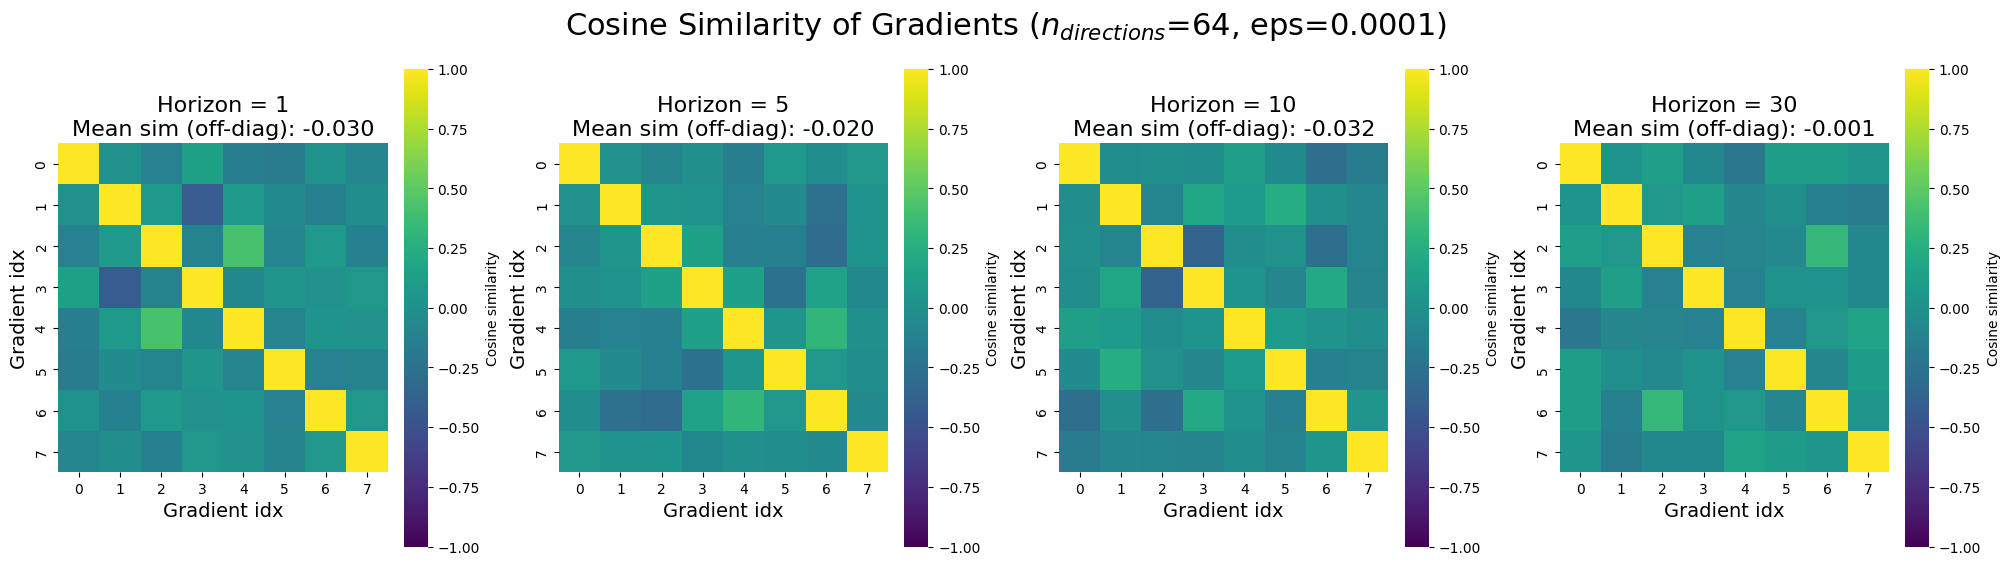

In [8]:
def cosine_similarity_matrix(vectors):
    # vectors: shape (n, d)
    norms = np.linalg.norm(vectors, axis=1, keepdims=True)
    norms[norms == 0] = 1e-12
    normalized = vectors / norms
    return np.dot(normalized, normalized.T)


# Select horizons and num_directions = 32
horizons = sorted(df_metadata['horizon'].unique())
num_directions_target = 64
perturbation_scale_target = 1e-4

# Set up subplots
n_horizons = len(horizons)
fig, axes = plt.subplots(1,
                         n_horizons,
                         figsize=(5 * n_horizons, 5),
                         constrained_layout=True)
if n_horizons == 1:
    axes = [axes]

mean_similarities = []

for idx, horizon in enumerate(horizons):
    subset = df_metadata[
        (df_metadata['horizon'] == horizon) &
        (df_metadata['num_directions'] == num_directions_target) &
        (df_metadata['perturbation_scale'] == perturbation_scale_target)]
    gradients = np.stack(subset['gradient'].values)
    sim_matrix = cosine_similarity_matrix(gradients)

    # Calculate mean cosine similarity excluding the diagonal
    n = sim_matrix.shape[0]
    mask = ~np.eye(n, dtype=bool)
    mean_cos_sim = sim_matrix[mask].mean() if np.sum(mask) > 0 else float('nan')
    mean_similarities.append(mean_cos_sim)

    ax = axes[idx]
    sns.heatmap(sim_matrix,
                ax=ax,
                cmap="viridis",
                vmin=-1,
                vmax=1,
                square=True,
                cbar_kws={'label': 'Cosine similarity'})
    ax.set_title(
        f"Horizon = {horizon}\nMean sim (off-diag): {mean_cos_sim:.3f}",
        fontsize=16)
    ax.set_xlabel("Gradient idx", fontsize=14)
    ax.set_ylabel("Gradient idx", fontsize=14)

fig.suptitle(
    f"Cosine Similarity of Gradients ($n_{{directions}}$={num_directions_target}, eps={perturbation_scale_target})",
    fontsize=22,
    y=1.1)
plt.show()


## Are top components shared between seeds?

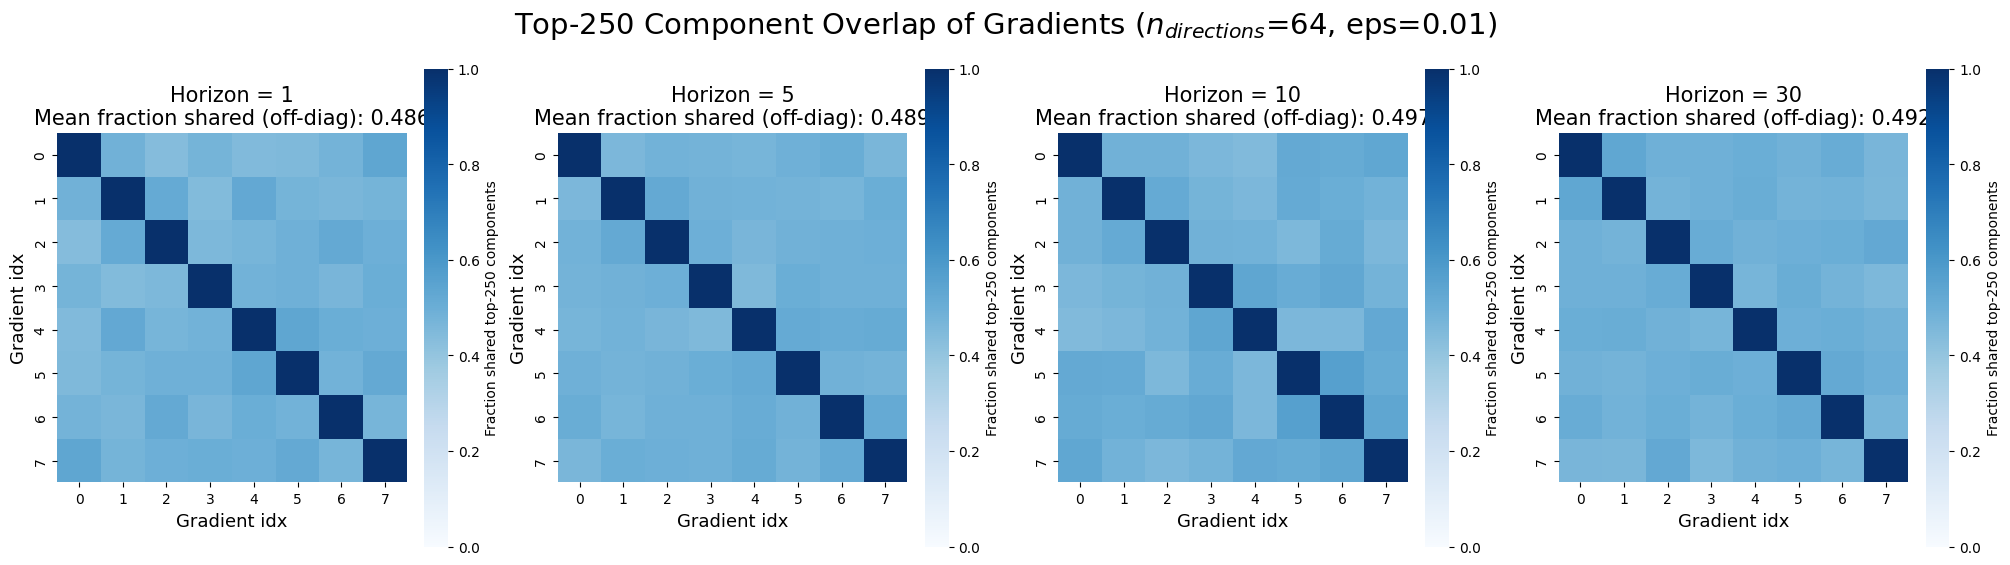

In [9]:
def topk_overlap_matrix(gradients, k=2):
    """
    Compute a matrix where entry (i, j) is the fraction of shared top-k components (by magnitude) 
    between gradients[i] and gradients[j].
    """
    n, d = gradients.shape
    # For each row, get indices of top-k absolute value components
    topk_indices = np.argpartition(-np.abs(gradients), k - 1, axis=1)[:, :k]
    # For fast lookup, turn each topk into a set (of the top-k indices)
    topk_sets = [set(topk_indices[i]) for i in range(n)]
    overlap_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            inter = topk_sets[i] & topk_sets[j]
            overlap_matrix[i, j] = len(inter) / k
    return overlap_matrix


# Select horizons and num_directions = 64
horizons = sorted(df_metadata['horizon'].unique())
num_directions_target = 64
perturbation_scale_target = 1e-2
topk = 250  # You can change this k

# Set up subplots
n_horizons = len(horizons)
fig, axes = plt.subplots(1,
                         n_horizons,
                         figsize=(5 * n_horizons, 5),
                         constrained_layout=True)
if n_horizons == 1:
    axes = [axes]

mean_topk_overlaps = []

for idx, horizon in enumerate(horizons):
    subset = df_metadata[
        (df_metadata['horizon'] == horizon) &
        (df_metadata['num_directions'] == num_directions_target) &
        (df_metadata['perturbation_scale'] == perturbation_scale_target)]
    gradients = np.stack(subset['gradient'].values)

    overlap_matrix = topk_overlap_matrix(gradients, k=topk)

    # Calculate mean top-k overlap excluding diagonal
    n = overlap_matrix.shape[0]
    mask = ~np.eye(n, dtype=bool)
    mean_overlap = overlap_matrix[mask].mean() if np.sum(mask) > 0 else float(
        'nan')
    mean_topk_overlaps.append(mean_overlap)

    ax = axes[idx]
    sns.heatmap(overlap_matrix,
                ax=ax,
                cmap="Blues",
                vmin=0,
                vmax=1,
                square=True,
                cbar_kws={'label': f'Fraction shared top-{topk} components'})
    ax.set_title(
        f"Horizon = {horizon}\nMean fraction shared (off-diag): {mean_overlap:.3f}",
        fontsize=15)
    ax.set_xlabel("Gradient idx", fontsize=13)
    ax.set_ylabel("Gradient idx", fontsize=13)

fig.suptitle(
    f"Top-{topk} Component Overlap of Gradients ($n_{{directions}}$={num_directions_target}, eps={perturbation_scale_target})",
    fontsize=21,
    y=1.1)
plt.show()


## Projection onto the first gradient

In [10]:
import torch

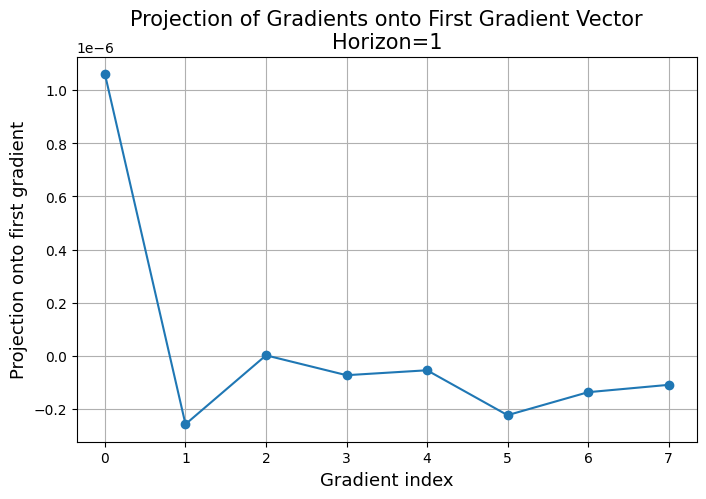

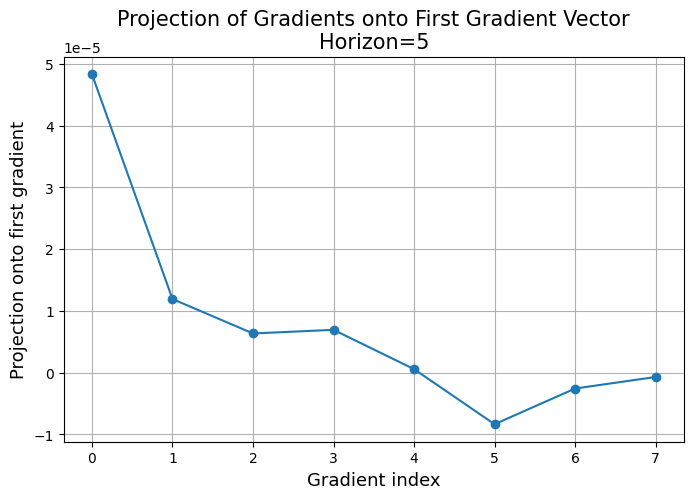

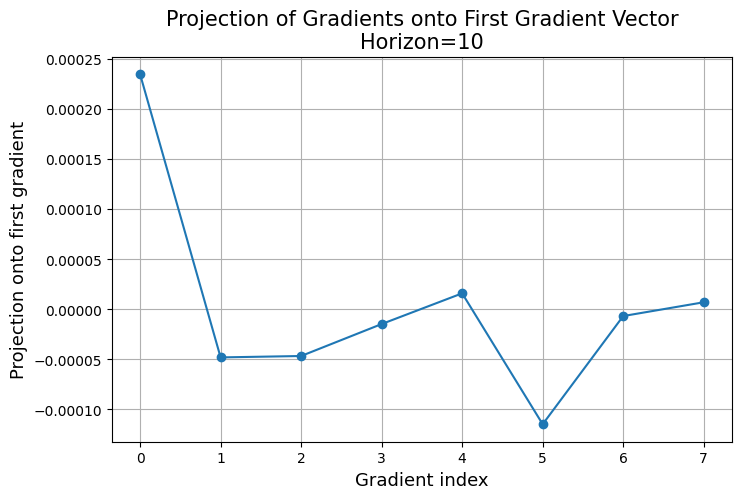

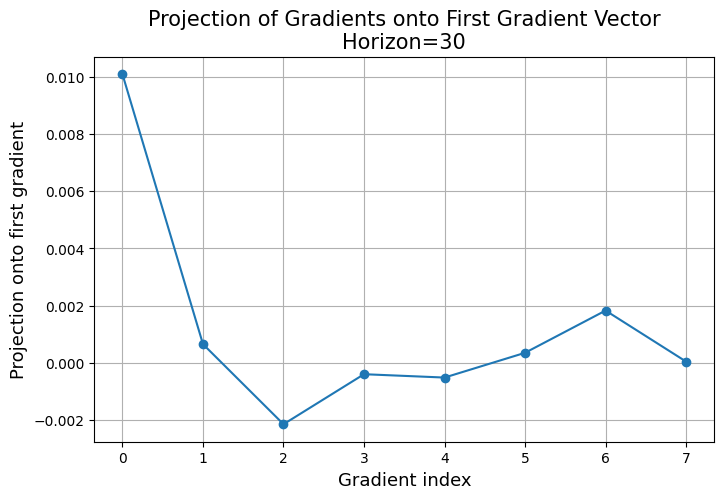

In [11]:
num_directions_target = 64
perturbation_scale_target = 1e-1
for idx, horizon in enumerate(horizons):
    subset = df_metadata[
        (df_metadata['horizon'] == horizon) &
        (df_metadata['num_directions'] == num_directions_target) &
        (df_metadata['perturbation_scale'] == perturbation_scale_target)]
    gradients = np.stack(subset['gradient'].values)

    if len(gradients) == 0:
        continue

    g0 = torch.tensor(gradients[0], dtype=torch.float32)
    g0_normalized = g0 / torch.norm(g0)
    projs = [
        torch.dot(torch.tensor(g_i, dtype=torch.float32), g0_normalized).item()
        for g_i in gradients
    ]

    plt.figure(figsize=(8, 5))
    plt.plot(projs, marker='o')
    plt.xlabel('Gradient index', fontsize=13)
    plt.ylabel('Projection onto first gradient', fontsize=13)
    plt.title(
        f'Projection of Gradients onto First Gradient Vector\nHorizon={horizon}',
        fontsize=15)
    plt.grid(True)
    plt.show()

## Is there any  low dimensional structure?

In [12]:
import numpy as np
import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Select only those rows with perturbation_scale in [1e-4, 1e-2] and num_directions==64
perturbation_scales = [1e-4, 1e-2, 1e-1]
num_directions_target = 64

subset = df_metadata[
    (df_metadata['num_directions'] == num_directions_target) &
    (df_metadata['perturbation_scale'].isin(perturbation_scales))]

gradients = np.stack(
    subset['gradient'].values)  # shape: (num_samples, gradient_dim)

# Normalize the gradients (L2 normalization)
normed_gradients = gradients / np.linalg.norm(gradients, axis=1, keepdims=True)

# Perform PCA
pca = PCA()
pca.fit(normed_gradients)
explained_variance = pca.explained_variance_ratio_
components = pca.transform(normed_gradients)


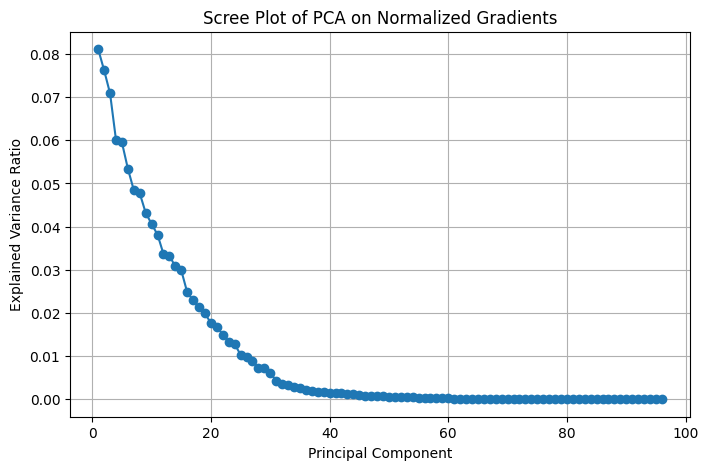

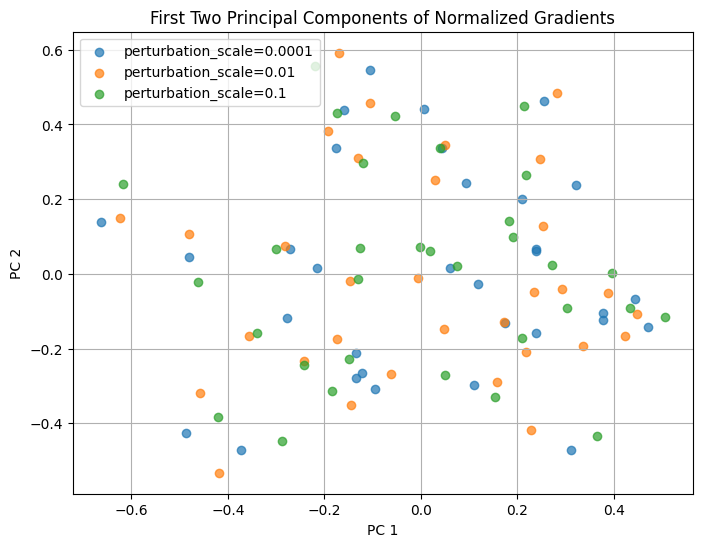

In [13]:
# Scree plot (explained variance by component)
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1,
                   len(explained_variance) + 1),
         explained_variance,
         marker='o')
plt.title('Scree Plot of PCA on Normalized Gradients')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

# Scatter plot of samples in first two principal components
plt.figure(figsize=(8, 6))
for scale in perturbation_scales:
    mask = np.isclose(subset['perturbation_scale'].values, scale)
    plt.scatter(components[mask, 0],
                components[mask, 1],
                label=f'perturbation_scale={scale:g}',
                alpha=0.7)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title('First Two Principal Components of Normalized Gradients')
plt.legend()
plt.grid(True)
plt.show()

## Save gradients for SPSA-sweep

In [14]:
num_directions_target = 64
perturbation_scale_targets = [1e-4, 1e-2]

df_analysis = df_metadata[
    (df_metadata['num_directions'] == num_directions_target) &
    (df_metadata['perturbation_scale'].isin(perturbation_scale_targets))]

# Compute "baseline gradients": random gradients matching stats of real ones (for 1e-4 and 1e-2 with different horizons)
chosen_scales = [1e-4, 1e-2]
horizons = sorted(df_metadata['horizon'].unique())

baseline_randoms = {}
num_seeds = 8
for seed in range(num_seeds):
    rng = np.random.default_rng(seed)
    for scale in chosen_scales:
        for h in horizons:
            subset = df_analysis[(df_analysis['horizon'] == h) &
                                 (df_analysis['perturbation_scale'] == scale)]
            # gradients should be a (num_samples, d) array where d is the gradient dimension
            gradients = np.stack(subset['gradient'].values)  # shape: (N, d)
            if gradients.ndim != 2:
                raise ValueError(
                    f"Expected 2d array for gradients, got {gradients.shape}")

            # Compute sample mean and covariance in d-dimensions
            mean = gradients.mean(axis=0)  # shape (d,)
            cov = np.cov(gradients, rowvar=False)  # shape (d, d)

            # Generate a single random d-dimensional sample (Gaussian), with same stats
            random_grad = rng.multivariate_normal(mean, cov,
                                                  size=None)  # shape: (d,)
            # Store for later
            key = (seed, scale, h, 'random')
            baseline_randoms[key] = random_grad

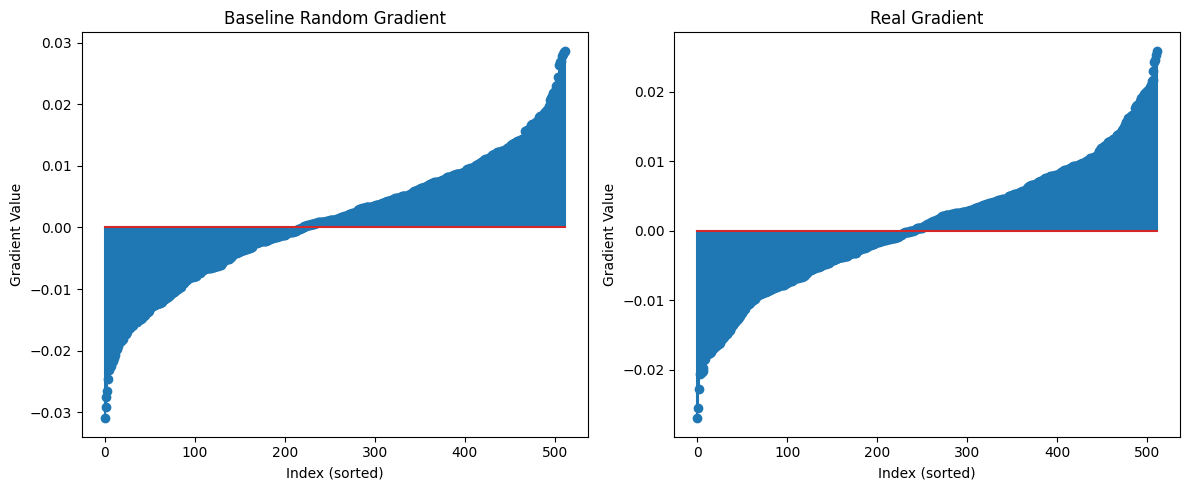

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot baseline random gradient
seed = 5
scale = 1e-4
horizon = 10
rg = baseline_randoms[(seed, scale, horizon, 'random')]
axes[0].stem(np.sort(rg))
axes[0].set_title("Baseline Random Gradient")
axes[0].set_xlabel("Index (sorted)")
axes[0].set_ylabel("Gradient Value")

# Plot real gradient
rg = df_analysis[(df_analysis['horizon'] == horizon) & (
    df_analysis['perturbation_scale'] == scale)]['gradient'].values[0]
axes[1].stem(np.sort(rg))
axes[1].set_title("Real Gradient")
axes[1].set_xlabel("Index (sorted)")
axes[1].set_ylabel("Gradient Value")

plt.tight_layout()
plt.show()

In [18]:
import pickle
import os
# Collect gradients from df_analysis in the same format as baseline_randoms
real_grads = {}
for idx, row in df_analysis.iterrows():
    key = (row['seed'], row['perturbation_scale'], row['horizon'], 'real')
    real_grads[key] = np.array(row['gradient'])

# Merge both dicts for saving
all_grads = {**baseline_randoms, **real_grads}

# Save to file
path_to_save = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/sweeps/sweep_data/031225-spsa-position'
with open(os.path.join(path_to_save, "spsa_gradients_x=0.pkl"), "wb") as f:
    pickle.dump(all_grads, f)
